In [34]:
import numpy as np
import pandas as pd
import lasio as las
from glob import glob
import matplotlib.pyplot as plt
import torch as pt
import gpytorch
import scipy
import os

from util.filehandler import read_las, save_gp_model, load_gp_model
from util.plotting import plot_well_logs
from util.well_processing import filter_wells_by_lithology, prepare_valid_tagilsk
from util.gaussian_processes import fit_gp_model_all_wells, predict_gp_model

ImportError: cannot import name 'save_gp_model' from 'util.filehandler' (/home/spaceswimmer/Documents/nnseismic/src/util/filehandler.py)

In [2]:
las_files = glob('/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/*Tgl*.las')
las_files

['/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-30.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-26.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/ZTgl-1.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-15.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-29.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-8.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=docume

In [3]:
# Create a dictionary to store all DataFrames
las_dfs = read_las(las_files)
# Keep only needed curves
las_dfs = prepare_valid_tagilsk(las_dfs)
# Display the keys (well names) in the dictionary
# del las_dfs['ZTgl-1']
print(f"\nTotal wells loaded: {len(las_dfs)}")
print(f"Well names: {list(las_dfs.keys())}")

Loaded: Tgl-30 - 4603 rows, 14 curves
Loaded: Tgl-26 - 6062 rows, 15 curves
Loaded: ZTgl-1 - 5408 rows, 12 curves
Loaded: Tgl-15 - 5898 rows, 14 curves
Loaded: Tgl-29 - 29873 rows, 14 curves
Loaded: Tgl-8 - 7623 rows, 16 curves
Loaded: Tgl-27 - 2377 rows, 12 curves
Processing well Tgl-30
Processing well Tgl-26
Processing well ZTgl-1
Processing well Tgl-15
Processing well Tgl-29
Processing well Tgl-8
Processing well Tgl-27

Total wells loaded: 7
Well names: ['Tgl-30', 'Tgl-26', 'ZTgl-1', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27']


## Processing wells, deleting trash data
### Manual trash data deletion

In [4]:
# Manual trash data deletion
# Tgl-29
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 3000)
las_dfs['Tgl-29'].loc[mask, 'DTP'] = np.nan
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 2398)
las_dfs['Tgl-29'].loc[mask, 'DTS'] = np.nan
# ZTgl-1
mask = (las_dfs['ZTgl-1']['DEPTH'] < 3150) & (las_dfs['ZTgl-1']['DEPTH'] > 2964)
las_dfs['ZTgl-1'].loc[mask, 'PL_GG'] = np.nan
# Tgl-8
mask = (las_dfs['Tgl-8']['DEPTH'] < 3150) & (las_dfs['Tgl-8']['DEPTH'] > 1846)
las_dfs['Tgl-8'].loc[mask, 'DTP'] = np.nan
mask = (las_dfs['Tgl-8']['DEPTH'] < 2656) & (las_dfs['Tgl-8']['DEPTH'] > 1840)
las_dfs['Tgl-8'].loc[mask, 'PL_GG'] = np.nan
# ZTgl-1
mask = (las_dfs['Tgl-27']['DEPTH'] < 3200) & (las_dfs['Tgl-27']['DEPTH'] > 1590)
las_dfs['Tgl-27'].loc[mask, 'DTP'] = np.nan
las_dfs = prepare_valid_tagilsk(las_dfs)

Processing well Tgl-30
Processing well Tgl-26
Processing well ZTgl-1
Processing well Tgl-15
Processing well Tgl-29
Processing well Tgl-8
Processing well Tgl-27


In [5]:
test = las_dfs['Tgl-27'][
    (las_dfs['Tgl-27']['DEPTH'] < 3200) & 
    (las_dfs['Tgl-27']['DEPTH'] > 1590)
]

(<Figure size 850x1200 with 5 Axes>,
 array([<Axes: title={'center': 'NAS'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'LITH'}>, <Axes: title={'center': 'DTP'}>,
        <Axes: title={'center': 'DTS'}>, <Axes: title={'center': 'PL_GG'}>],
       dtype=object))

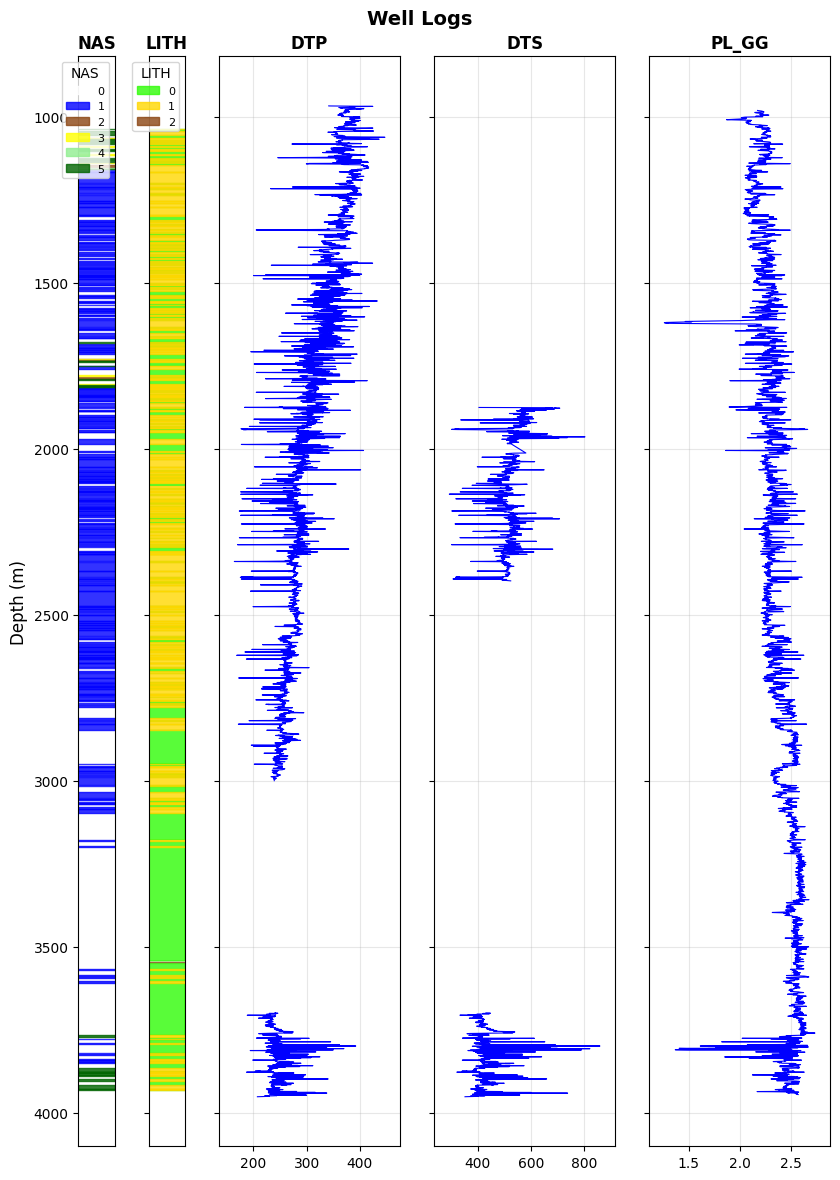

In [6]:
plot_well_logs(las_dfs['Tgl-29'], ['NAS', 'LITH', 'DTP', 'DTS', 'PL_GG'])

In [7]:
las_dfs_shale = {}
las_dfs_brine_sand = {}
las_dfs_oil_sand = {}
las_dfs_gas_sand = {}

# Apply filtering to all wells
las_dfs_shale, las_dfs_brine_sand, las_dfs_oil_sand, las_dfs_gas_sand = filter_wells_by_lithology(las_dfs)

Tgl-30: shale=2260, brine=1707, oil=142, gas=4
Tgl-26: shale=2806, brine=2255, oil=446, gas=94
ZTgl-1: shale=2184, brine=2217, oil=0, gas=0
Tgl-15: shale=2430, brine=1939, oil=427, gas=285
Tgl-29: shale=15536, brine=12102, oil=1081, gas=194
Tgl-8: shale=3158, brine=723, oil=1774, gas=55
Tgl-27: shale=848, brine=46, oil=215, gas=34


# Probabalistic models implementation

VP: R² = 0.957, kernel = 0.888**2 * RBF(length_scale=2.45) + WhiteKernel(noise_level=0.0629)


<Axes: title={'center': 'GP Model: VP'}, xlabel='Depth (m)', ylabel='VP'>

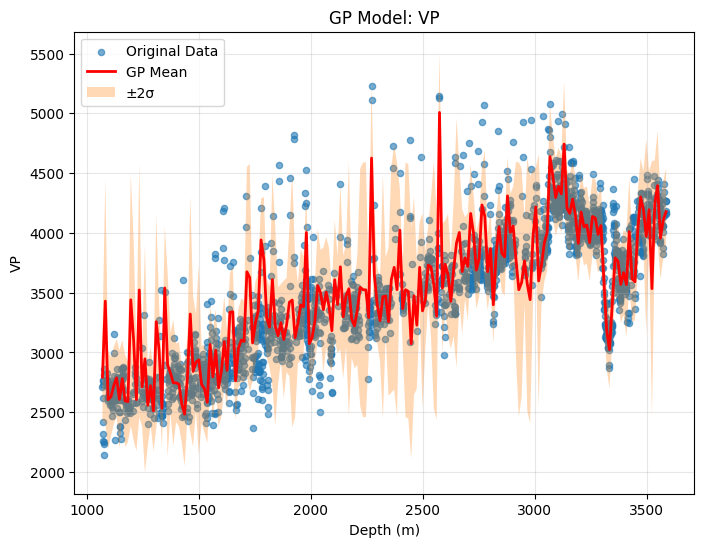

In [ ]:
from util.gaussian_processes_sklearn import fit_gp_model_sklearn
from util.plotting import plot_gp_model

result = fit_gp_model_sklearn(las_dfs_shale['Tgl-30'], 'VP')
plot_gp_model(result, 'VP')

In [8]:
pt.cuda.is_available()

True

In [9]:
las_dfs_shale.keys()

dict_keys(['Tgl-30', 'Tgl-26', 'ZTgl-1', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27'])

In [10]:
result_shale = fit_gp_model_all_wells(
    las_dfs_shale,
    property_col=['PL_GG', 'VP', 'VS'],
    max_points=10000,
    training_iter=100,
    lengthscale=0.1
)

Using 29222 total points for ['PL_GG', 'VP', 'VS']


Training GP for ['PL_GG', 'VP', 'VS']:   1%|          | 1/100 [00:09<15:21,  9.31s/it]

Iteration 0, Loss: 1.3348


Training GP for ['PL_GG', 'VP', 'VS']:   6%|▌         | 6/100 [00:54<14:46,  9.43s/it]

Iteration 5, Loss: 1.2530


...

Iteration 90, Loss: 1.1286


Training GP for ['PL_GG', 'VP', 'VS']:  96%|█████████▌| 96/100 [14:17<00:36,  9.17s/it]

Iteration 95, Loss: 1.1282


Training GP for ['PL_GG', 'VP', 'VS']: 100%|██████████| 100/100 [14:51<00:00,  8.92s/it]

['PL_GG', 'VP', 'VS']: trained on 6001 points


In [18]:
result_shale

{'model': MultitaskGPModel(
   (likelihood): MultitaskGaussianLikelihood(
     (raw_task_noises_constraint): GreaterThan(1.000E-04)
     (raw_noise_constraint): GreaterThan(1.000E-04)
   )
   (mean_module): MultitaskMean(
     (base_means): ModuleList(
       (0-2): 3 x ConstantMean()
     )
   )
   (covar_module): MultitaskKernel(
     (task_covar_module): IndexKernel(
       (raw_var_constraint): Positive()
     )
     (data_covar_module): RBFKernel(
       (raw_lengthscale_constraint): GreaterThan(1.000E-01)
     )
   )
 ),
 'likelihood': MultitaskGaussianLikelihood(
   (raw_task_noises_constraint): GreaterThan(1.000E-04)
   (raw_noise_constraint): GreaterThan(1.000E-04)
 ),
 'scaler_x': StandardScaler(),
 'scaler_y': StandardScaler(),
 'depth_range': (np.float64(1250.0), np.float64(3933.0))}

In [23]:
x_new = np.linspace(result_shale['depth_range'][0], result_shale['depth_range'][1], 500)
means, stds = predict_gp_model(result_shale, x_new)

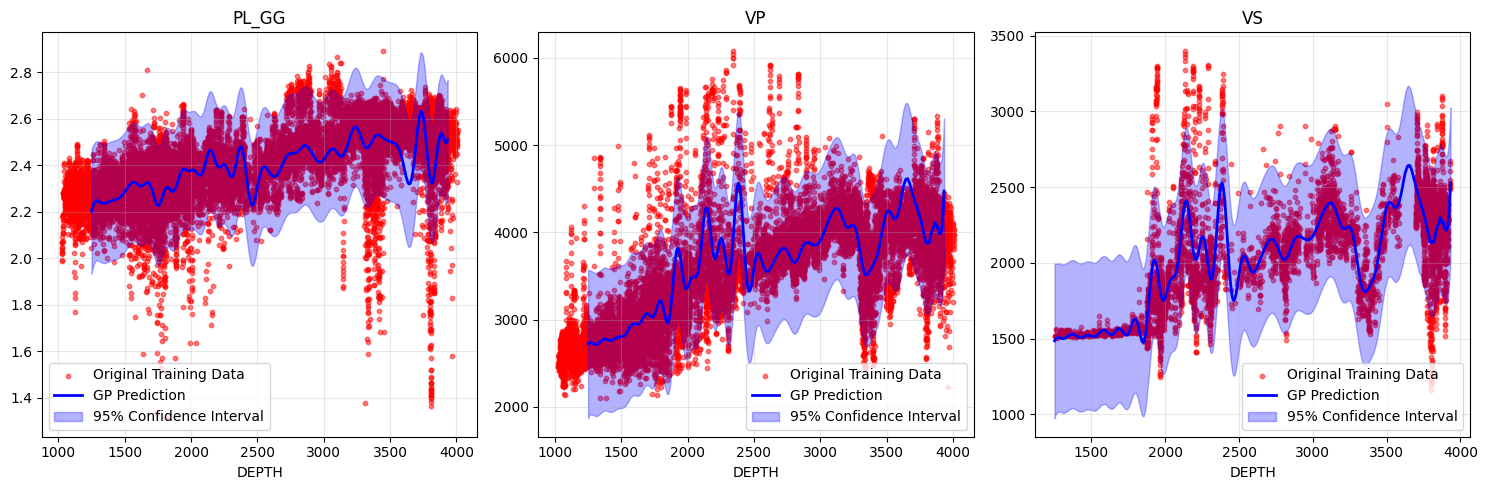

In [ ]:
from util.plotting import visualize_multichannel_gp_results_side_by_side
all_data = []
for well_name, df in las_dfs_shale.items():
    app_data = df[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result_shale, ['PL_GG', 'VP', 'VS'], combined_df)

In [39]:
from util.gaussian_processes import MultitaskGPModel
def save_gp_model(gp_result, filepath):
    """
    Save a GP model and its associated components to a file using PyTorch.
    
    Args:
        gp_result: Dictionary containing the GP model and related components
                   Expected keys: 'model', 'likelihood', 'scaler_x', 'scaler_y', 'depth_range'
        filepath: Path where the model should be saved
    """
    # Get the hyperparameters from the model
    model = gp_result['model']
    
    # Prepare the state dictionary with all necessary parameters
    state_dict = {
        'model_state_dict': model.state_dict(),
        'likelihood_state_dict': gp_result['likelihood'].state_dict(),
        'model_type': type(model).__name__,
        'num_tasks': getattr(model, 'num_tasks', 1),
        'scaler_x': gp_result['scaler_x'],
        'scaler_y': gp_result['scaler_y'],
        'depth_range': gp_result['depth_range']
    }
    
    # Save the state dictionary
    pt.save(state_dict, filepath)
    print(f"GP model saved to {filepath}")

save_gp_model(result_shale, '../data/models/shale_v1.pth')

GP model saved to ../data/models/shale_v1.pth


Tgl-30
Tgl-26
ZTgl-1
Tgl-15
Tgl-29
Tgl-8
Tgl-27


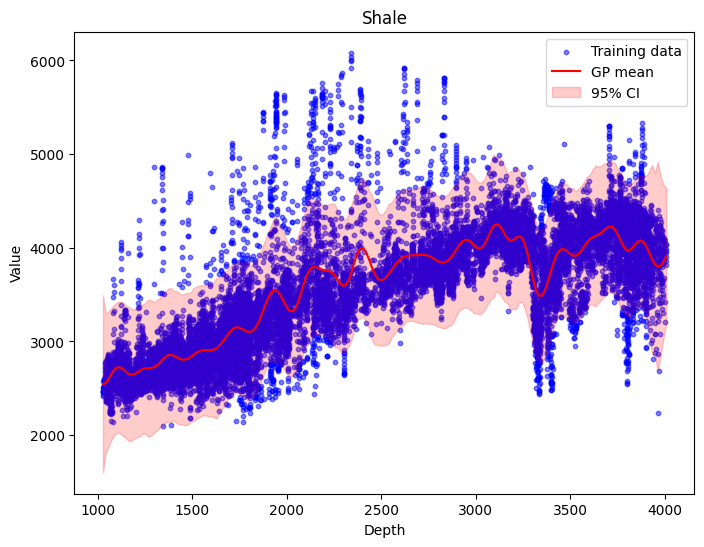

In [13]:
def plot_gp_result(gp_result: dict, x_train: np.ndarray, y_train: np.ndarray, title: str = None):
    """
    Simple plot of GP results with training data and uncertainty.
    
    Parameters
    ----------
    gp_result : dict
        Result from fit_gp_model()
    x_train : array
        Training depth values
    y_train : array
        Training property values
    title : str, optional
        Plot title
    """
    # Predict on smooth range
    x_range = np.linspace(gp_result['depth_range'][0], gp_result['depth_range'][1], 200)
    mean, std = predict_gp_model(gp_result, x_range)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x_train, y_train, c='blue', s=10, alpha=0.5, label='Training data')
    plt.plot(x_range, mean, 'r-', label='GP mean')
    plt.fill_between(x_range, mean - 2*std, mean + 2*std, alpha=0.2, color='red', label='95% CI')
    plt.xlabel('Depth')
    plt.ylabel('Value')
    if title:
        plt.title(title)
    plt.legend()
    plt.show()
all_data = []
    
for well_name, df in las_dfs_shale.items():
    app_data = df[['DEPTH', 'VP']]
    all_data.append(app_data)
    print(well_name)
combined_df = pd.concat(all_data, ignore_index=True)
plot_gp_result(result_shale, combined_df['DEPTH'], combined_df['VP'], title='Shale')

In [28]:
# Check what the model learned
result = result_shale['likelihood']
model = result_shale['model']

print("Model hyperparameters:")
print(f"  Lengthscale: {model.covar_module.base_kernel.lengthscale.item():.2f}")
print(f"  Output scale: {model.covar_module.outputscale.item():.2f}")
print(f"  Noise: {result.noise.item():.6f}")
print(f"  Mean constant: {model.mean_module.constant.item():.2f}")

Model hyperparameters:
  Lengthscale: 0.01
  Output scale: 4.19
  Noise: 0.308745
  Mean constant: -0.86


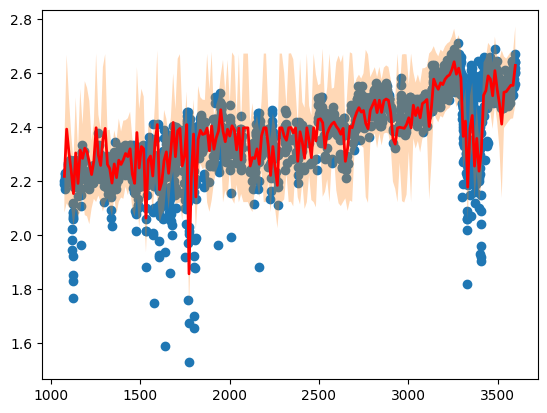

In [ ]:
x = las_dfs_shale['Tgl-15']['DEPTH']
y = las_dfs_shale['Tgl-15']['PL_GG']
x_smooth = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_mean, y_std = result['model'].predict(x_smooth, return_std=True)
plt.scatter(x, y)
plt.plot(x_smooth, y_mean, 'r-', label='GP Mean', linewidth=2)
plt.fill_between(x_smooth.flatten(), 
                y_mean - 2*y_std, 
                y_mean + 2*y_std, 
                alpha=0.3, label='±2σ')


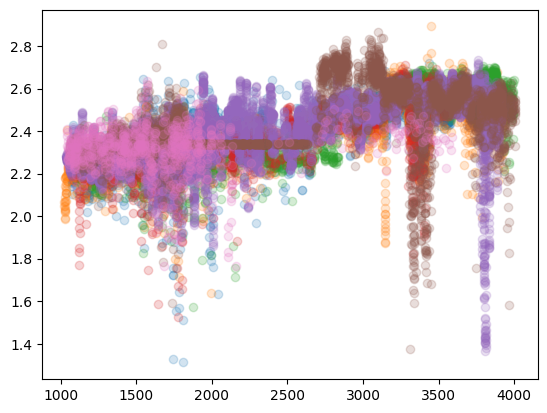

In [ ]:
for well in las_dfs_shale.keys():
    x = las_dfs_shale[well]['DEPTH']
    y = las_dfs_shale[well]['PL_GG']
    plt.scatter(x, y, alpha=0.2)